In [ ]:
import numpy as np 
import pandas as pd

In [36]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv("Advertising.csv")

In [7]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [8]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


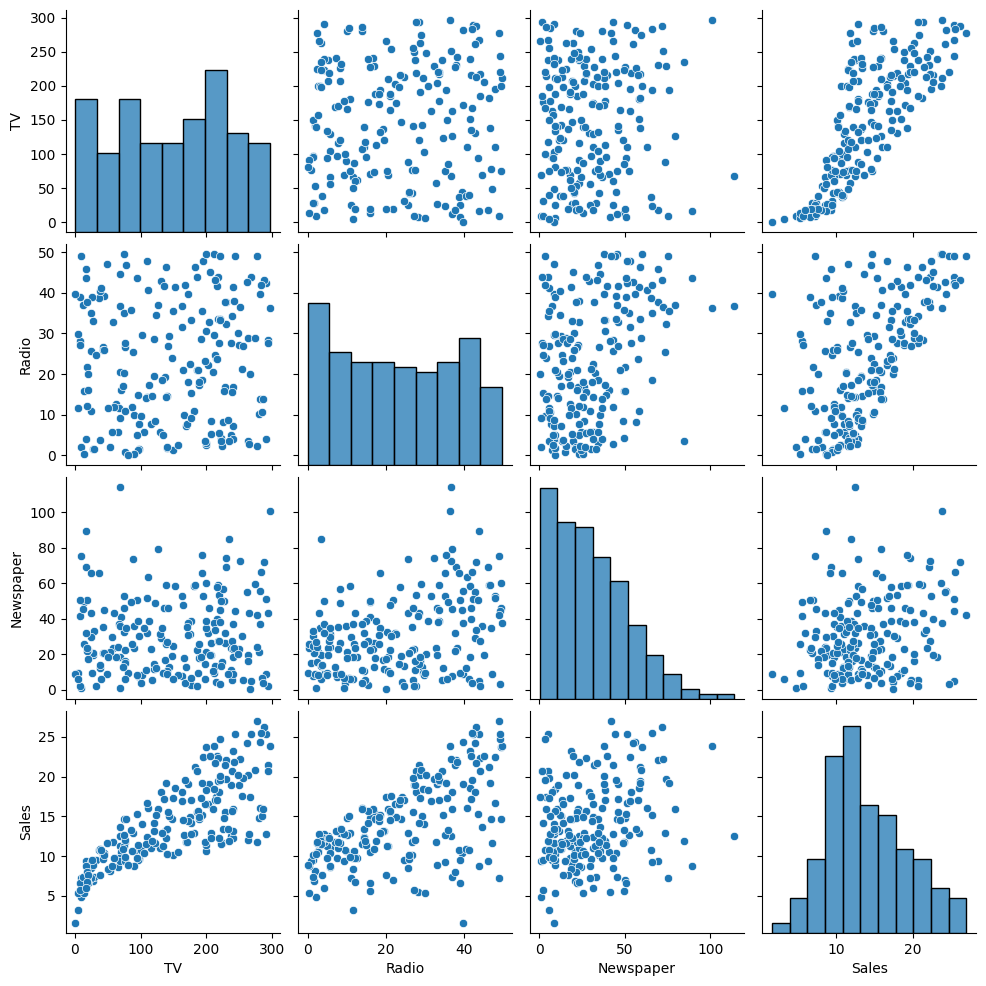

In [10]:
sns.pairplot(df)

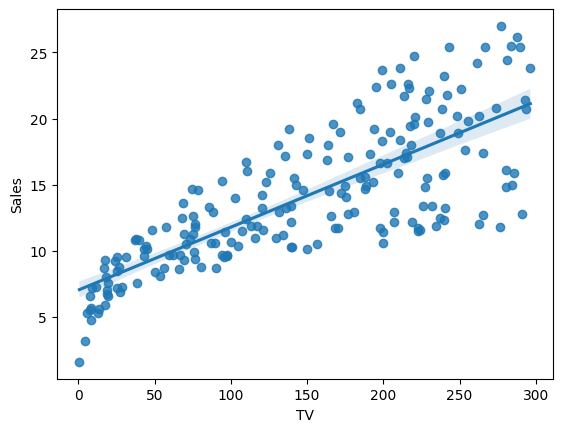

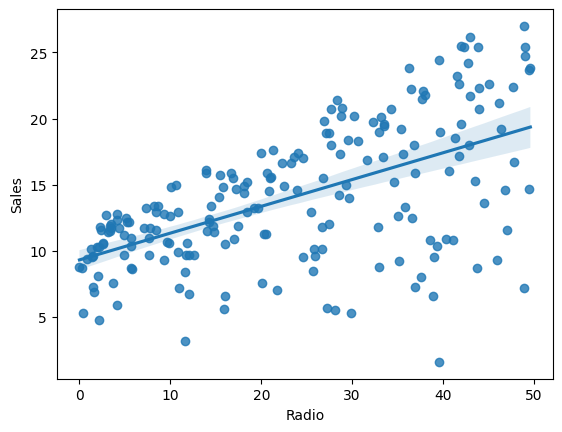

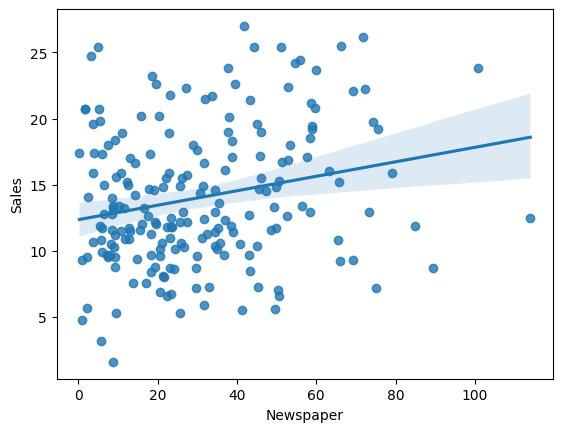

In [16]:
for i in ["TV", "Radio", "Newspaper"]:
    sns.regplot(x=i, y="Sales", data=df)
    plt.show()
    

In [24]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [25]:
x = df.drop("Sales", axis=1)
y = df["Sales"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [31]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((180, 3), (20, 3), (180,), (20,))

In [26]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [27]:
pred = model.predict(x_test)

In [28]:
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

MAE: 1.3694443359949906
MSE: 3.1308020912380483


In [29]:
1.4607567168117603 / y_test.mean() * 100

np.float64(10.73691081816803)

In [30]:
print("r2_score:", r2_score(y_test, pred))

r2_score: 0.9046924770871361


In [38]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [39]:
try1 = model.predict([[230.1, 37.8, 69.2]])
try2 = model.predict([[44.5, 39.3, 45.1]])
try3 = model.predict([[17.2, 45.9, 69.3]])
try4 = model.predict([[151.5, 41.3, 58.5]])
try5 = model.predict([[180.8, 10.8, 58.4]])

print(try1)
print(try2)
print(try3)
print(try4)
print(try5)

[20.55326833]
[12.41582955]
[12.45013939]
[17.63655765]
[13.31183263]


In [40]:
# to show the final w, b
print(model.coef_)
print(model.intercept_)

[0.0451046  0.18511831 0.00181341]
3.05174080901943
